La Min Oo 6540039</br>
Set Kaung Lwin 6632017</br>
Sein Win Htut  6611040</br>

In [7]:
import os
import joblib
import pandas as pd
from sk.features import extract_features
import warnings
import parselmouth
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=parselmouth.PraatWarning)

sample_rate = 22050

emotion_encoder = joblib.load(os.path.join("models", "svm_emotion_encoder_improv.pkl"))
intensity_encoder = joblib.load(os.path.join("models", "svm_intensity_encoder_improv.pkl"))
gender_encoder = joblib.load(os.path.join("models", "svm_gender_encoder_improv.pkl"))

multi_svm = joblib.load(os.path.join("models", "svm_multi_improv.pkl"))
test_metadata = pd.read_csv('test_metadata_master.csv')

In [10]:
file_path = "/Users/setkaung/Documents/Code/nlp_project/sk/sk_test_audios/audio1.wav"
feature = extract_features(file_path)
predictions = multi_svm.predict(feature.reshape(1, -1))[0]

predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

print("Emotion: ", predicted_emotion)
print("Intensity: ", predicted_intensity)
print("Gender: ", predicted_gender)

Emotion:  angry
Intensity:  strong
Gender:  female


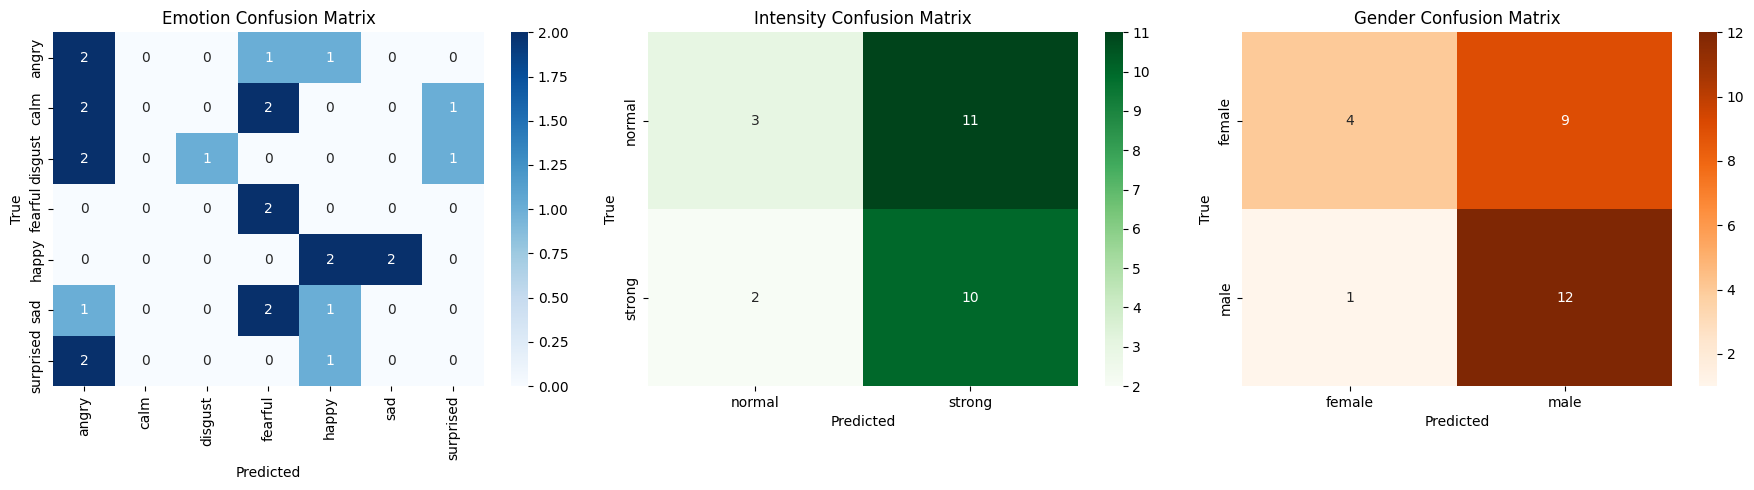

Overall Accuracy
Emotion Accuracy:   26.92%
Intensity Accuracy: 50.00%
Gender Accuracy:    61.54%
Emotion
              precision    recall  f1-score   support

       angry       0.22      0.50      0.31         4
        calm       0.00      0.00      0.00         5
     disgust       1.00      0.25      0.40         4
     fearful       0.29      1.00      0.44         2
       happy       0.40      0.50      0.44         4
         sad       0.00      0.00      0.00         4
   surprised       0.00      0.00      0.00         3

    accuracy                           0.27        26
   macro avg       0.27      0.32      0.23        26
weighted avg       0.27      0.27      0.21        26

Intensity
              precision    recall  f1-score   support

      normal       0.60      0.21      0.32        14
      strong       0.48      0.83      0.61        12

    accuracy                           0.50        26
   macro avg       0.54      0.52      0.46        26
weighted avg   

In [2]:
true_emotions = []
pred_emotions = []
true_intensities = []
pred_intensities = []
true_genders = []
pred_genders = []

for _, row in test_metadata.iterrows():
    file_path = row['file_path']
    try:
        feature = extract_features(file_path)
        predictions = multi_svm.predict(feature.reshape(1, -1))[0]

        predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
        predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
        predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

        true_emotions.append(str(row['Emotion']).lower())
        pred_emotions.append(predicted_emotion)
        true_intensities.append(str(row['Intensity']).lower())
        pred_intensities.append(predicted_intensity)
        true_genders.append(str(row['Gender']).lower())
        pred_genders.append(predicted_gender)
    except Exception as e:
        print(f"Error processing {file_path}: {type(e).__name__}: {e}")

if len(true_emotions) == 0:
    print("No predictions were collected. Check file paths and model compatibility.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm_emotion = confusion_matrix(true_emotions, pred_emotions, labels=emotion_encoder.classes_)
    sns.heatmap(
        cm_emotion,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[0],
        xticklabels=emotion_encoder.classes_,
        yticklabels=emotion_encoder.classes_
    )
    axes[0].set_title('Emotion Confusion Matrix')
    axes[0].set_ylabel('True')
    axes[0].set_xlabel('Predicted')

    cm_intensity = confusion_matrix(true_intensities, pred_intensities, labels=intensity_encoder.classes_)
    sns.heatmap(
        cm_intensity,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=axes[1],
        xticklabels=intensity_encoder.classes_,
        yticklabels=intensity_encoder.classes_
    )
    axes[1].set_title('Intensity Confusion Matrix')
    axes[1].set_ylabel('True')
    axes[1].set_xlabel('Predicted')

    cm_gender = confusion_matrix(true_genders, pred_genders, labels=gender_encoder.classes_)
    sns.heatmap(
        cm_gender,
        annot=True,
        fmt='d',
        cmap='Oranges',
        ax=axes[2],
        xticklabels=gender_encoder.classes_,
        yticklabels=gender_encoder.classes_
    )
    axes[2].set_title('Gender Confusion Matrix')
    axes[2].set_ylabel('True')
    axes[2].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    emotion_acc = accuracy_score(true_emotions, pred_emotions)
    intensity_acc = accuracy_score(true_intensities, pred_intensities)
    gender_acc = accuracy_score(true_genders, pred_genders)

    print("Overall Accuracy")

    print(f"Emotion Accuracy:   {emotion_acc:.2%}")
    print(f"Intensity Accuracy: {intensity_acc:.2%}")
    print(f"Gender Accuracy:    {gender_acc:.2%}")

    print("Emotion")
    print(classification_report(
        true_emotions,
        pred_emotions,
        labels=emotion_encoder.classes_,
        target_names=emotion_encoder.classes_,
        zero_division=0
    ))

    print("Intensity")
    print(classification_report(
        true_intensities,
        pred_intensities,
        labels=intensity_encoder.classes_,
        target_names=intensity_encoder.classes_,
        zero_division=0
    ))

    print("Gender")
    print(classification_report(
        true_genders,
        pred_genders,
        labels=gender_encoder.classes_,
        target_names=gender_encoder.classes_,
        zero_division=0
    ))